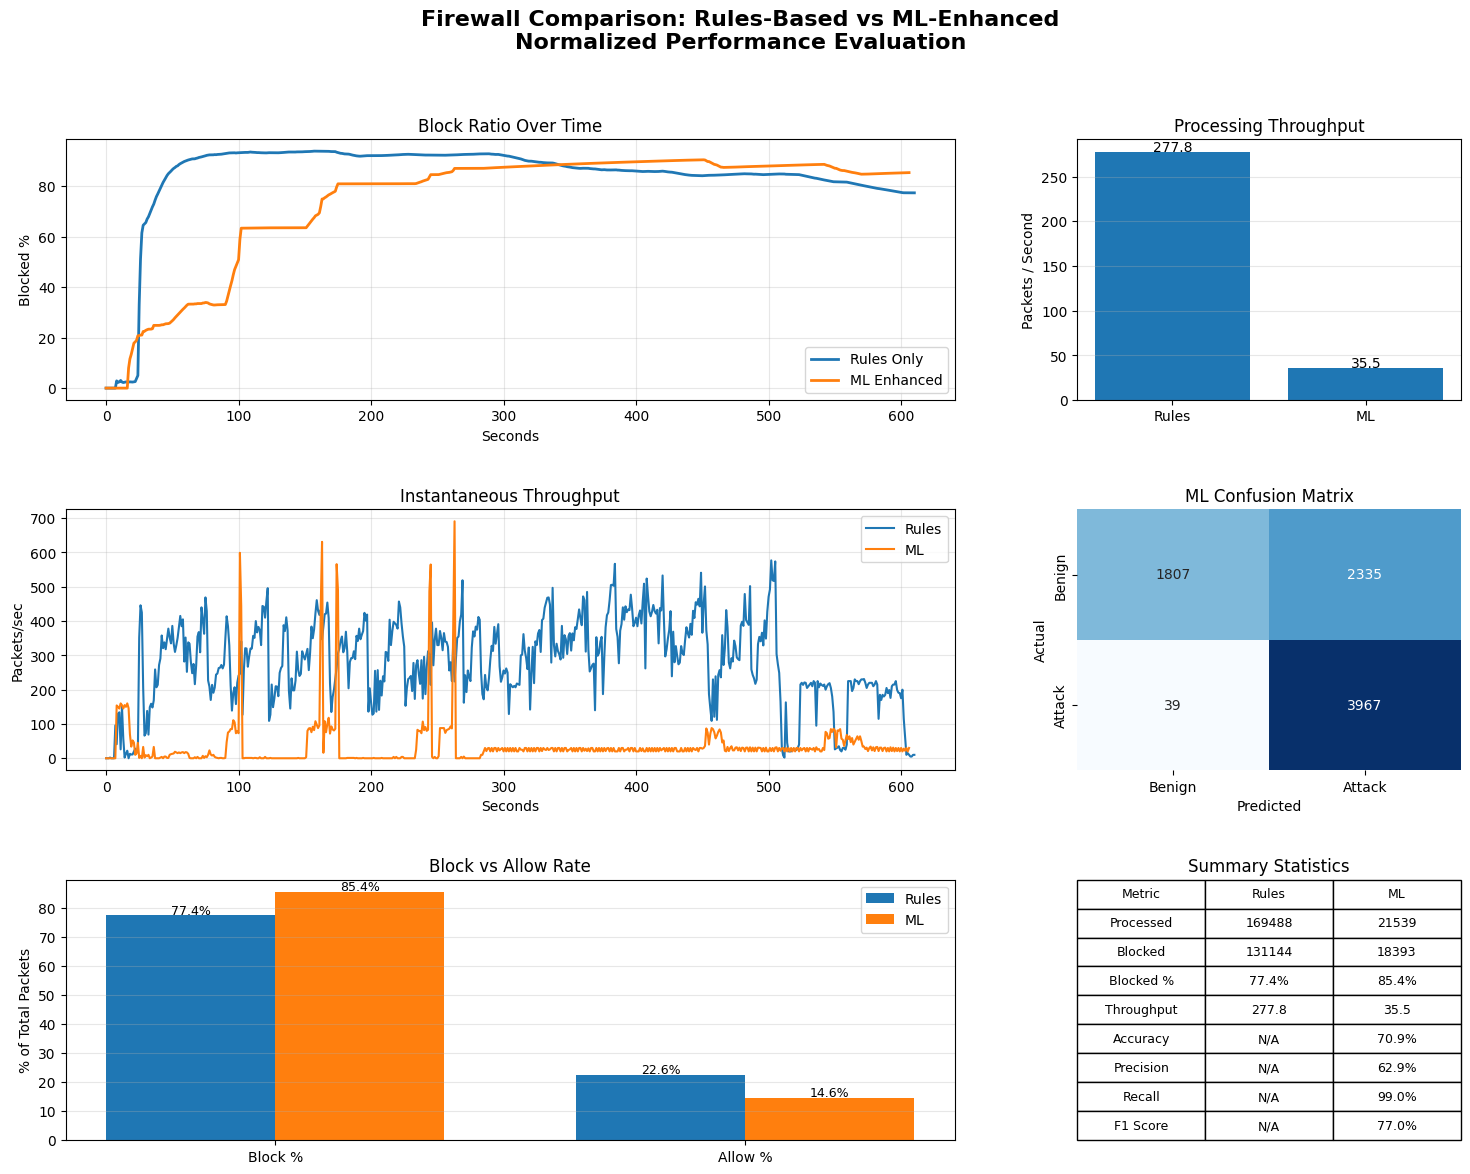

[+] Saved firewall_comparison_corrected.png


In [ ]:
# compare_experiments.py
# Fair comparison of Rules-Only vs ML-Enhanced Firewall
# Uses normalized metrics instead of misleading raw totals

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns

# ==========================================================
# LOAD FILES
# ==========================================================

rules_log = pd.read_csv("experiment_rules_only.csv")
ml_log    = pd.read_csv("experiment_ml_enabled.csv")

# ML prediction logs
dfs = []
for file in ["ml_results_0.csv", "ml_results_1.csv"]:
    try:
        dfs.append(pd.read_csv(file))
    except FileNotFoundError:
        pass

ml_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def processed_packets(df):
    return df["packets_allowed"] + df["packets_blocked_total"]

def safe_div(a, b):
    return a / b if b != 0 else 0

def cumulative_ratio(num, denom):
    out = []
    for n, d in zip(num, denom):
        out.append(n / d if d > 0 else 0)
    return np.array(out)

# ==========================================================
# FINAL VALUES
# ==========================================================

rules_time = rules_log["elapsed_seconds"].iloc[-1]
ml_time    = ml_log["elapsed_seconds"].iloc[-1]

rules_processed = processed_packets(rules_log)
ml_processed    = processed_packets(ml_log)

rules_total_processed = rules_processed.iloc[-1]
ml_total_processed    = ml_processed.iloc[-1]

rules_total_blocked = rules_log["packets_blocked_total"].iloc[-1]
ml_total_blocked    = ml_log["packets_blocked_total"].iloc[-1]

rules_total_allowed = rules_log["packets_allowed"].iloc[-1]
ml_total_allowed    = ml_log["packets_allowed"].iloc[-1]

# ==========================================================
# NORMALIZED METRICS
# ==========================================================

rules_pps = safe_div(rules_total_processed, rules_time)
ml_pps    = safe_div(ml_total_processed, ml_time)

rules_block_ratio = safe_div(rules_total_blocked, rules_total_processed)
ml_block_ratio    = safe_div(ml_total_blocked, ml_total_processed)

rules_allow_ratio = safe_div(rules_total_allowed, rules_total_processed)
ml_allow_ratio    = safe_div(ml_total_allowed, ml_total_processed)

# ==========================================================
# ML CLASSIFICATION METRICS
# ==========================================================

acc = prec = rec = f1 = 0
cm = None

if not ml_df.empty and ml_df["y_true"].nunique() > 1:
    y_true = ml_df["y_true"]
    y_pred = ml_df["y_pred"]

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

# ==========================================================
# FIGURE SETUP
# ==========================================================

fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    "Firewall Comparison: Rules-Based vs ML-Enhanced\n"
    "Normalized Performance Evaluation",
    fontsize=16,
    fontweight="bold"
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

# ==========================================================
# PANEL 1 — Block Ratio Over Time
# ==========================================================

ax1 = fig.add_subplot(gs[0, :2])

rules_ratio_time = cumulative_ratio(
    rules_log["packets_blocked_total"],
    processed_packets(rules_log)
)

ml_ratio_time = cumulative_ratio(
    ml_log["packets_blocked_total"],
    processed_packets(ml_log)
)

ax1.plot(
    rules_log["elapsed_seconds"],
    rules_ratio_time * 100,
    label="Rules Only",
    linewidth=2
)

ax1.plot(
    ml_log["elapsed_seconds"],
    ml_ratio_time * 100,
    label="ML Enhanced",
    linewidth=2
)

ax1.set_title("Block Ratio Over Time")
ax1.set_xlabel("Seconds")
ax1.set_ylabel("Blocked %")
ax1.legend()
ax1.grid(alpha=0.3)

# ==========================================================
# PANEL 2 — Packets/sec bar chart (moved from panel 5)
# ==========================================================
 
ax2 = fig.add_subplot(gs[0, 2])
 
labels = ["Rules", "ML"]
vals   = [rules_pps, ml_pps]
 
bars = ax2.bar(labels, vals)
 
for b in bars:
    ax2.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 1,
        f"{b.get_height():.1f}",
        ha="center"
    )
 
ax2.set_title("Processing Throughput")
ax2.set_ylabel("Packets / Second")
ax2.grid(axis="y", alpha=0.3)
 
# ==========================================================
# PANEL 3 — Instantaneous Throughput
# ==========================================================
 
ax3 = fig.add_subplot(gs[1, :2])
 
rules_rate = processed_packets(rules_log).diff().fillna(0)
ml_rate    = processed_packets(ml_log).diff().fillna(0)
 
ax3.plot(rules_log["elapsed_seconds"], rules_rate, label="Rules")
ax3.plot(ml_log["elapsed_seconds"], ml_rate, label="ML")
 
ax3.set_title("Instantaneous Throughput")
ax3.set_xlabel("Seconds")
ax3.set_ylabel("Packets/sec")
ax3.legend()
ax3.grid(alpha=0.3)
 
# ==========================================================
# PANEL 4 — Confusion Matrix
# ==========================================================
 
ax4 = fig.add_subplot(gs[1, 2])
 
if cm is not None:
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"],
        ax=ax4
    )
    ax4.set_title("ML Confusion Matrix")
    ax4.set_xlabel("Predicted")
    ax4.set_ylabel("Actual")
else:
    ax4.text(
        0.5, 0.5,
        "No ML Labels Available",
        ha="center",
        va="center"
    )
    ax4.set_title("Confusion Matrix")
 
# ==========================================================
# PANEL 5 — Block % / Allow % grouped bar chart
# ==========================================================
 
ax5 = fig.add_subplot(gs[2, :2])
 
ratio_metrics  = ["Block %", "Allow %"]
rules_ratios   = [rules_block_ratio * 100, rules_allow_ratio * 100]
ml_ratios      = [ml_block_ratio * 100,    ml_allow_ratio * 100]
 
x = np.arange(len(ratio_metrics))
w = 0.36
 
bars1 = ax5.bar(x - w / 2, rules_ratios, w, label="Rules")
bars2 = ax5.bar(x + w / 2, ml_ratios,   w, label="ML")
 
for b in list(bars1) + list(bars2):
    ax5.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.5,
        f"{b.get_height():.1f}%",
        ha="center",
        fontsize=9
    )
 
ax5.set_xticks(x)
ax5.set_xticklabels(ratio_metrics)
ax5.set_ylabel("% of Total Packets")
ax5.set_title("Block vs Allow Rate")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
 
# ==========================================================
# PANEL 6 — Summary Table
# ==========================================================
 
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
 
table_data = [
    ["Metric", "Rules", "ML"],
    ["Processed", int(rules_total_processed), int(ml_total_processed)],
    ["Blocked",   int(rules_total_blocked),   int(ml_total_blocked)],
    ["Blocked %", f"{rules_block_ratio:.1%}", f"{ml_block_ratio:.1%}"],
    ["Throughput", f"{rules_pps:.1f}",        f"{ml_pps:.1f}"],
    ["Accuracy",  "N/A",                      f"{acc:.1%}"],
    ["Precision", "N/A",                      f"{prec:.1%}"],
    ["Recall",    "N/A",                      f"{rec:.1%}"],
    ["F1 Score",  "N/A",                      f"{f1:.1%}"],
]
 
table = ax6.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
 
table.auto_set_font_size(False)
table.set_fontsize(9)
 
ax6.set_title("Summary Statistics")
 
# ==========================================================
# SAVE
# ==========================================================
 
plt.savefig("firewall_comparison_normalised.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("[+] Saved firewall_comparison_normalised.png")